Keyword Extraction Using KeyBERT.

Imports the model and packages.

In [1]:
from keybert import KeyBERT
import pandas as pd

c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\transformers\utils\generic.py:441: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  _torch_pytree._register_pytree_node(
c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\transformers\utils\generic.py:309: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  _torch_pytree._register_pytree_node(


KeyBert starts by embedding a document into a vector by turning a chunk of text into a fixed sized vector which represents the semnatics of the document. It then extracts key words using simple techniques - count vectorizer, TFADF vectorizer
Embeds each word using the same model used to embed the document, leaving a list of keyword embeddings. 
Similarity measures will be calculated between document and keyword embeddings. This results in a vector, where each value is a similarity measure between the two. Sorts results in decreasing order to get the most simliar words. 

Adding diversity in the data:
Sometimes there is some redundancy in the data, and repetition. 
Max Sum Similarity
Maximal Marginal Relevance

In [2]:
model = KeyBERT(model = "distilbert-base-nli-mean-tokens")

In [4]:
all_feedback = pd.read_csv('..\\proutectapp\\csv-json-files\\joinedfeedback.csv')
ratings = all_feedback.loc[:, ['Latitude', 'Longitude', 'q1', 'q2', 'q3', 'q4']]
responses =  all_feedback.loc[:, ['Latitude', 'Longitude', 'responseList']]

,Latitude,Longitude,responseList
0,52.285500,-1.558030,"The route was busy with the public, but there ..."
1,52.286880,-1.533620,"There was a long, isolated road with a lack of..."
2,52.279250,-1.544650,"There was a long, isolated road with a lack of..."
3,52.290777,-1.533494,The route was busy with the public as there we...
4,52.275950,-1.516430,"Well-lit street, was quite busy with other mem..."
...,...,...,...
779,52.292370,-1.548190,A really nice walk to do in the evening.; The ...
780,52.285970,-1.536280,The route felt fairly safe with some street li...
781,52.282960,-1.545510,The route felt fairly safe with some street li...
782,52.288400,-1.538270,Walking through the park made me feel uneasy a...


Need to classify each coordinate to be safe/unsafe utilising user feedback. Used average of all answers to question 1 "How safe did you feel on the route?" 

In [5]:
classification_list = []
for index, row in ratings.iterrows():
    if row["q1"] > 2.5:
        classification_list.append("safe")
    else:
        classification_list.append("unsafe")

ratings["Classification"] = classification_list
ratings["Classification"].value_counts()

Classification
safe      413
unsafe    371
Name: count, dtype: int64

In [6]:
ratings['q2'] = ratings['q2'] / 5
ratings['q3'] = ratings['q3'] / 5
ratings['q4'] = ratings['q4'] / 5

The following blocks of code were used to test different metrics of the Keyword Extraction Model. 

In [7]:
from keyphrase_vectorizers import KeyphraseCountVectorizer

In [8]:
keywords_list = []

for index, row in responses.iterrows():
  
    doc = row["responseList"]

    keywords = model.extract_keywords(doc, keyphrase_ngram_range=(1,2), stop_words='english', use_mmr=True, diversity=0.9)

    keywords_list.append(keywords)

responses['Keywords_2'] = keywords_list
    

In [9]:
keywords_list = []

for index, row in responses.iterrows():
  
    doc = row["responseList"]

    keywords = model.extract_keywords(doc, keyphrase_ngram_range=(1,1), stop_words='english', use_mmr=True, diversity=0.9)

    keywords_list.append(keywords)

responses['Keywords'] = keywords_list

In [10]:
keywords_list = []

for index, row in responses.iterrows():
  
    doc = row["responseList"]

    keywords = model.extract_keywords(doc, keyphrase_ngram_range=(1,3), stop_words='english', use_mmr=True, diversity=0.9)

    keywords_list.append(keywords)

responses['Keywords_3'] = keywords_list

In [11]:
keywords_list = []

for index, row in responses.iterrows():
  
    doc = row["responseList"]

    keywords = model.extract_keywords(doc, vectorizer=KeyphraseCountVectorizer(), stop_words='english', use_mmr=True, diversity=0.9)

    keywords_list.append(keywords)

responses['Keywords_Vect'] = keywords_list

In [12]:
combined_df = pd.merge(ratings, responses, on=["Latitude", "Longitude"])

In [13]:
from collections import defaultdict

safe_keywords = combined_df[combined_df["Classification"] == "safe"]["Keywords"].explode()
unsafe_keywords = combined_df[combined_df["Classification"] == "unsafe"]["Keywords"].explode()

safe_keywords_scores = defaultdict(list)
unsafe_keywords_scores = defaultdict(list)

for keyword, score in safe_keywords:
    safe_keywords_scores[keyword].append(score)

for keyword, score in unsafe_keywords:
    unsafe_keywords_scores[keyword].append(score)

safe_summary = {keyword: (max(scores), len(scores)) for keyword, scores in safe_keywords_scores.items()}
unsafe_summary = {keyword: (max(scores), len(scores)) for keyword, scores in unsafe_keywords_scores.items()}

top_safe_keywords = sorted(safe_summary.items(), key=lambda x: x[1][1], reverse=True)[:10]
top_unsafe_keywords = sorted(unsafe_summary.items(), key=lambda x: x[1][1], reverse=True)[:10]


In [14]:
from collections import defaultdict

safe_keywords = combined_df[combined_df["Classification"] == "safe"]["Keywords_2"].explode()
unsafe_keywords = combined_df[combined_df["Classification"] == "unsafe"]["Keywords_2"].explode()

safe_keywords_scores = defaultdict(list)
unsafe_keywords_scores = defaultdict(list)

for keyword, score in safe_keywords:
    safe_keywords_scores[keyword].append(score)

for keyword, score in unsafe_keywords:
    unsafe_keywords_scores[keyword].append(score)

safe_summary = {keyword: (max(scores), len(scores)) for keyword, scores in safe_keywords_scores.items()}
unsafe_summary = {keyword: (max(scores), len(scores)) for keyword, scores in unsafe_keywords_scores.items()}
top_safe_keywords = sorted(safe_summary.items(), key=lambda x: x[1][1], reverse=True)[:10]
top_unsafe_keywords = sorted(unsafe_summary.items(), key=lambda x: x[1][1], reverse=True)[:10]

In [15]:
safe_keywords = combined_df[combined_df["Classification"] == "safe"]["Keywords_3"].explode()
unsafe_keywords = combined_df[combined_df["Classification"] == "unsafe"]["Keywords_3"].explode()

safe_keywords_scores = defaultdict(list)
unsafe_keywords_scores = defaultdict(list)

for keyword, score in safe_keywords:
    safe_keywords_scores[keyword].append(score)

for keyword, score in unsafe_keywords:
    unsafe_keywords_scores[keyword].append(score)

safe_summary = {keyword: (max(scores), len(scores)) for keyword, scores in safe_keywords_scores.items()}
unsafe_summary = {keyword: (max(scores), len(scores)) for keyword, scores in unsafe_keywords_scores.items()}

top_safe_keywords = sorted(safe_summary.items(), key=lambda x: x[1][1], reverse=True)[:10]
top_unsafe_keywords = sorted(unsafe_summary.items(), key=lambda x: x[1][1], reverse=True)[:10]

In [16]:
safe_keywords = combined_df[combined_df["Classification"] == "safe"]["Keywords_Vect"].explode()
unsafe_keywords = combined_df[combined_df["Classification"] == "unsafe"]["Keywords_Vect"].explode()

safe_keywords_scores = defaultdict(list)
unsafe_keywords_scores = defaultdict(list)

for keyword, score in safe_keywords:
    safe_keywords_scores[keyword].append(score)

for keyword, score in unsafe_keywords:
    unsafe_keywords_scores[keyword].append(score)

safe_summary = {keyword: (max(scores), len(scores)) for keyword, scores in safe_keywords_scores.items()}
unsafe_summary = {keyword: (max(scores), len(scores)) for keyword, scores in unsafe_keywords_scores.items()}

top_safe_keywords = sorted(safe_summary.items(), key=lambda x: x[1][1], reverse=True)[:10]
top_unsafe_keywords = sorted(unsafe_summary.items(), key=lambda x: x[1][1], reverse=True)[:10]

In [17]:
safe_keywords = combined_df[combined_df["Classification"] == "safe"]["Keywords"].explode()
unsafe_keywords = combined_df[combined_df["Classification"] == "unsafe"]["Keywords"].explode()

safe_keywords_dict = {}
unsafe_keywords_dict = {}

for keyword, score in safe_keywords:
    if keyword not in safe_keywords_dict or safe_keywords_dict[keyword] < score:
        safe_keywords_dict[keyword] = score

for keyword, score in unsafe_keywords:
    if keyword not in unsafe_keywords_dict or unsafe_keywords_dict[keyword] < score:
        unsafe_keywords_dict[keyword] = score

top_safe_keywords = sorted(safe_keywords_dict.items(), key=lambda x: x[1], reverse=True)[:10]
top_unsafe_keywords = sorted(unsafe_keywords_dict.items(), key=lambda x: x[1], reverse=True)[:10]

top_safe_words = [keyword for keyword, _ in top_safe_keywords]
top_unsafe_words = [keyword for keyword, _ in top_unsafe_keywords]


In [18]:
import pandas as pd
from operator import itemgetter

safe_keywords = combined_df[combined_df["Classification"] == "safe"]["Keywords_2"].explode()
unsafe_keywords = combined_df[combined_df["Classification"] == "unsafe"]["Keywords_2"].explode()

safe_keywords_dict = {}
unsafe_keywords_dict = {}

for keyword, score in safe_keywords:
    if keyword not in safe_keywords_dict or safe_keywords_dict[keyword] < score:
        safe_keywords_dict[keyword] = score

for keyword, score in unsafe_keywords:
    if keyword not in unsafe_keywords_dict or unsafe_keywords_dict[keyword] < score:
        unsafe_keywords_dict[keyword] = score

top_safe_keywords = sorted(safe_keywords_dict.items(), key=lambda x: x[1], reverse=True)[:10]
top_unsafe_keywords = sorted(unsafe_keywords_dict.items(), key=lambda x: x[1], reverse=True)[:10]

top_safe_words = [keyword for keyword, _ in top_safe_keywords]
top_unsafe_words = [keyword for keyword, _ in top_unsafe_keywords]

In [19]:
safe_keywords = combined_df[combined_df["Classification"] == "safe"]["Keywords_3"].explode()
unsafe_keywords = combined_df[combined_df["Classification"] == "unsafe"]["Keywords_3"].explode()

safe_keywords_dict = {}
unsafe_keywords_dict = {}

for keyword, score in safe_keywords:
    if keyword not in safe_keywords_dict or safe_keywords_dict[keyword] < score:
        safe_keywords_dict[keyword] = score

for keyword, score in unsafe_keywords:
    if keyword not in unsafe_keywords_dict or unsafe_keywords_dict[keyword] < score:
        unsafe_keywords_dict[keyword] = score

top_safe_keywords = sorted(safe_keywords_dict.items(), key=lambda x: x[1], reverse=True)[:10]
top_unsafe_keywords = sorted(unsafe_keywords_dict.items(), key=lambda x: x[1], reverse=True)[:10]

top_safe_words = [keyword for keyword, _ in top_safe_keywords]
top_unsafe_words = [keyword for keyword, _ in top_unsafe_keywords]

In [20]:
safe_keywords = combined_df[combined_df["Classification"] == "safe"]["Keywords_Vect"].explode()
unsafe_keywords = combined_df[combined_df["Classification"] == "unsafe"]["Keywords_Vect"].explode()

safe_keywords_dict = {}
unsafe_keywords_dict = {}

for keyword, score in safe_keywords:
    if keyword not in safe_keywords_dict or safe_keywords_dict[keyword] < score:
        safe_keywords_dict[keyword] = score

for keyword, score in unsafe_keywords:
    if keyword not in unsafe_keywords_dict or unsafe_keywords_dict[keyword] < score:
        unsafe_keywords_dict[keyword] = score

top_safe_keywords = sorted(safe_keywords_dict.items(), key=lambda x: x[1], reverse=True)[:10]
top_unsafe_keywords = sorted(unsafe_keywords_dict.items(), key=lambda x: x[1], reverse=True)[:10]

top_safe_words = [keyword for keyword, _ in top_safe_keywords]
top_unsafe_words = [keyword for keyword, _ in top_unsafe_keywords]

In [21]:
combined_df.to_csv('C:\\Users\\User\\Documents\\GitHub\\proutectapp\\csv-json-files\\combined_feedback.csv', index=False)

The following blocks of code plots scatter graphs of the datasets.

In [22]:
import matplotlib.pyplot as plt
df = pd.read_csv(output_file)
plt.figure(figsize=(10, 6))
plt.scatter(df['Longitude'], df['Latitude'], c=df['Safety Score'], cmap='viridis', s=100) 
plt.colorbar(label='Safety Score')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Scatter Plot of Safety Scores')
plt.grid(True)
plt.show()

NameError: name 'output_file' is not defined

In [ ]:
output_file = "C:\\Users\\User\\Documents\\GitHub\\proutectapp\\csv-json-files\\training_set_new.csv"

df = pd.read_csv(output_file)
plt.figure(figsize=(10, 6))
plt.scatter(df['Longitude'], df['Latitude'], c=df['Safety Score'], cmap='viridis', s=100)  # s is size
plt.colorbar(label='Safety Score')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Scatter Plot of Safety Scores')
plt.grid(True)
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\User\\Documents\\GitHub\\proutectapp\\csv-json-files\\training_set_new.csv'

38.574827917744585
38.505734295489574
784


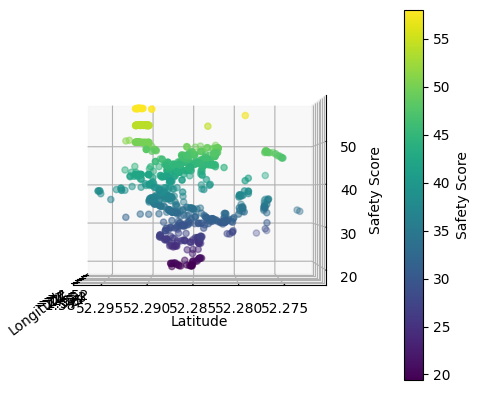

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df is your DataFrame with 'longitude', 'latitude', 'safety score'
output_file = "C:\\Users\\User\\Documents\\GitHub\\proutectapp\\training_set_after_averages.csv"

df = pd.read_csv(output_file)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

x = df['Longitude']
y = df['Latitude']
z = df['Safety Score']

# Scatter plot
sc = ax.scatter(x, y, z, c=z, cmap='viridis')  # Color by safety score, using a colormap
plt.colorbar(sc, label='Safety Score')  # Add colorbar to represent the safety score scale

# Setting the front view
ax.view_init(elev=0, azim=180)  # Adjust azimuth for the desired front orientation


ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_zlabel('Safety Score')

plt.show()


77
31.67446538071906
63.71270194531907


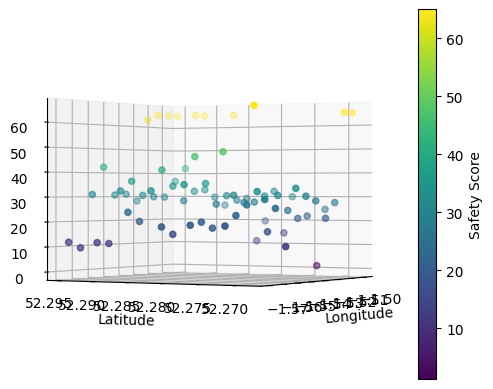

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df is your DataFrame with 'longitude', 'latitude', 'safety score'
output_file = "C:\\Users\\User\\Documents\\GitHub\\proutectapp\\training_set_averages.csv"

df = pd.read_csv(output_file)
print(len(df))
print(df["Safety Score"].mean())
print(df["Safety Score"].max() - df["Safety Score"].min())

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

x = df['Longitude']
y = df['Latitude']
z = df['Safety Score']

# Scatter plot
sc = ax.scatter(x, y, z, c=z, cmap='viridis')  # Color by safety score, using a colormap
plt.colorbar(sc, label='Safety Score')  # Add colorbar to represent the safety score scale

# Setting the front view
ax.view_init(elev=0, azim=-150)  # Adjust azimuth for the desired front orientation

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_zlabel('Safety Score')

plt.show()
